<a href="https://colab.research.google.com/github/asmaamuhamed20/Toxic-Content-Classification/blob/main/Toxic_content_classification_week_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("/content/drive/MyDrive/Cellula_1week_Asmaa/cellula_toxic_data.csv")

print("Data Shape:", df.shape)
print("\n Columns:", df.columns.tolist())
print("\n Toxic Categories Distribution:")
print(df['Toxic Category'].value_counts())

# Convert to binary classification (Safe vs Toxic)
df['label'] = df['Toxic Category'].apply(lambda x: 0 if x == 'Safe' else 1)
print("\n Label distribution after conversion:")
label_counts = df['label'].value_counts()
print(label_counts)
print(f"Toxic ratio: {df['label'].mean():.2%}")

# Text analysis
texts = df['image descriptions'].tolist()
labels = df['label'].tolist()

print(f"\n Text analysis:")
print(f"Number of texts: {len(texts)}")
print(f"Toxic ratio in data: {np.mean(labels):.2%}")

Data Shape: (3000, 3)

 Columns: ['query', 'image descriptions', 'Toxic Category']

 Toxic Categories Distribution:
Toxic Category
Safe                         995
Violent Crimes               792
Non-Violent Crimes           301
unsafe                       274
Unknown S-Type               196
Sex-Related Crimes           115
Suicide & Self-Harm          114
Elections                    110
Child Sexual Exploitation    103
Name: count, dtype: int64

 Label distribution after conversion:
label
1    2005
0     995
Name: count, dtype: int64
Toxic ratio: 66.83%

 Text analysis:
Number of texts: 3000
Toxic ratio in data: 66.83%


In [34]:
texts = df['image descriptions'].tolist()
labels = df['label'].tolist()

# Split data
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")
print(f"Toxic ratio in training: {np.mean(train_labels):.2%}")
print(f"Toxic ratio in validation: {np.mean(val_labels):.2%}")

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

print(f"Class Weights: {class_weights}")

Training samples: 2400
Validation samples: 600
Toxic ratio in training: 66.83%
Toxic ratio in validation: 66.83%
Class Weights: [1.50753769 0.74812968]


In [40]:

from transformers import (
    DistilBertTokenizer, DistilBertForSequenceClassification,
    Trainer, TrainingArguments
)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

# Dataset Class
class ToxicDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text, truncation=True, padding='max_length',
            max_length=self.max_length, return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Training Arguments
training_args = TrainingArguments(
    output_dir='./results_simple',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1e-5,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=20,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='none'
)

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)

    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted'),
        'precision': precision_score(labels, predictions, average='weighted'),
        'recall': recall_score(labels, predictions, average='weighted')
    }

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

train_dataset = ToxicDataset(train_texts, train_labels, tokenizer)
val_dataset = ToxicDataset(val_texts, val_labels, tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

training_results = trainer.train()


# Final evaluation
final_metrics = trainer.evaluate()
print("\n📊 Final Results:")
for key, value in final_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.376400,0.381095,0.776667,0.782393,0.866537,0.776667
2,0.339900,0.377040,0.776667,0.782393,0.866537,0.776667
3,0.348000,0.374605,0.776667,0.782393,0.866537,0.776667
4,0.378900,0.377121,0.776667,0.782393,0.866537,0.776667
5,0.397300,0.375650,0.776667,0.782393,0.866537,0.776667



📊 Final Results:
eval_loss: 0.3811
eval_accuracy: 0.7767
eval_f1: 0.7824
eval_precision: 0.8665
eval_recall: 0.7767
eval_runtime: 2.2475
eval_samples_per_second: 266.9600
eval_steps_per_second: 16.9070
epoch: 5.0000


In [43]:
trainer.save_model('toxic_classifier_trained')
tokenizer.save_pretrained('toxic_classifier_trained')
print("Model saved successfully!")

final_results = trainer.evaluate()
print("\n FINAL TRAINING RESULTS:")
print("=" * 40)
for key, value in final_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")

import json
with open('training_results1.json', 'w') as f:
    json.dump(final_results, f, indent=2)

Model saved successfully!



 FINAL TRAINING RESULTS:
eval_loss: 0.3811
eval_accuracy: 0.7767
eval_f1: 0.7824
eval_precision: 0.8665
eval_recall: 0.7767
eval_runtime: 2.3442
eval_samples_per_second: 255.9500
eval_steps_per_second: 16.2100
epoch: 5.0000


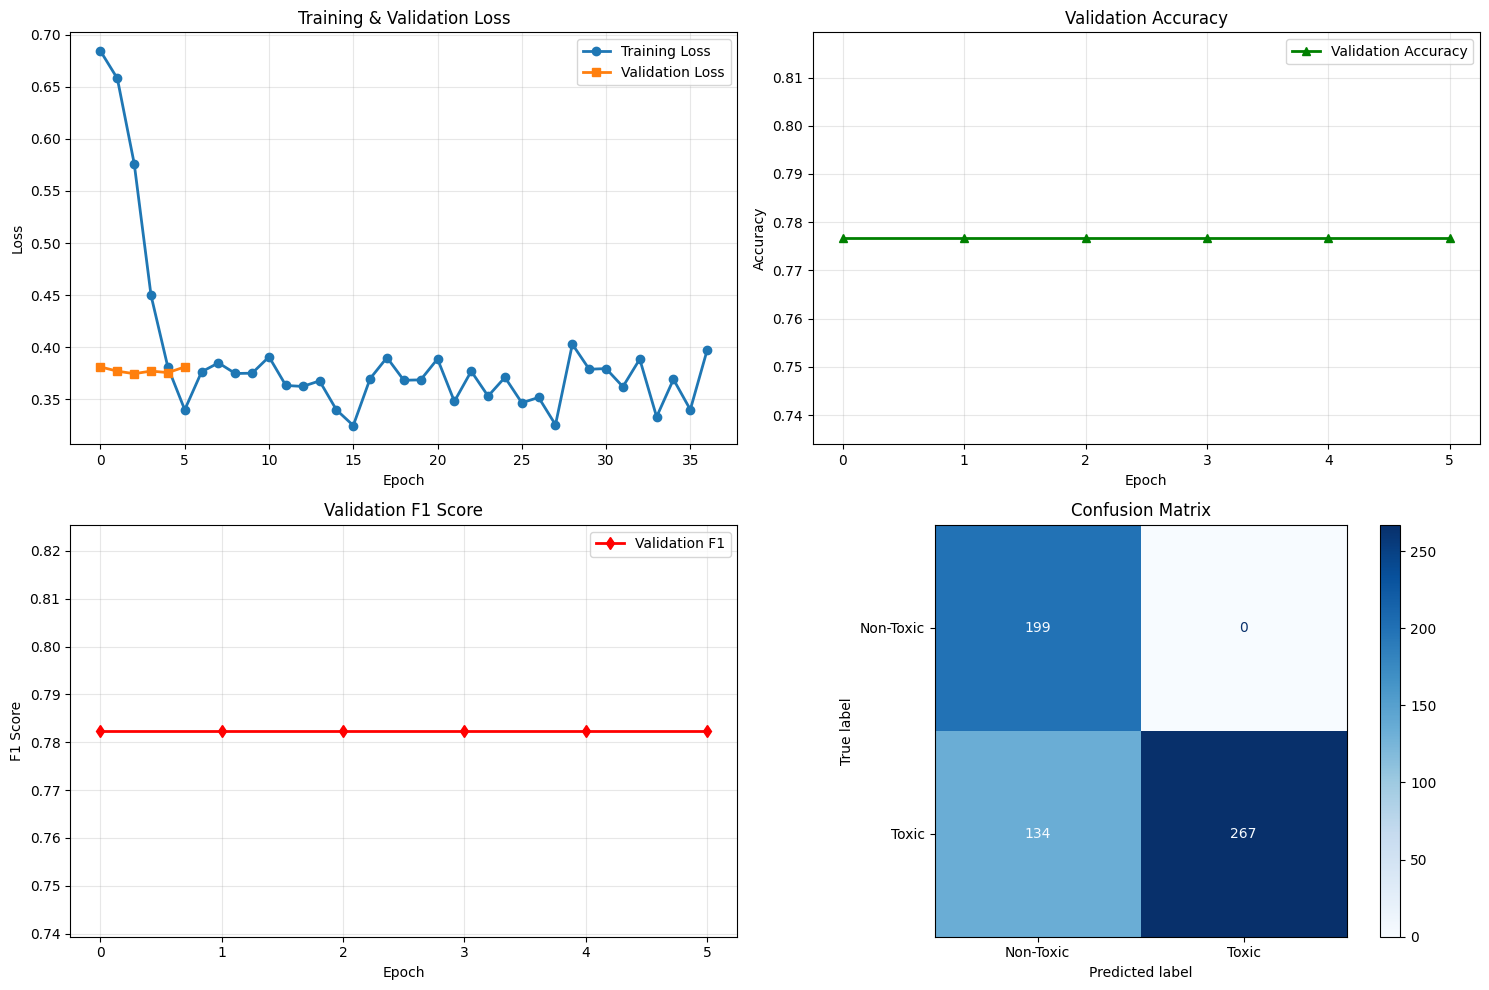

In [41]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))


history = trainer.state.log_history

# Loss
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

axes[0,0].plot(train_loss, label='Training Loss', marker='o', linewidth=2)
axes[0,0].plot(eval_loss, label='Validation Loss', marker='s', linewidth=2)
axes[0,0].set_title('Training & Validation Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Accuracy
eval_accuracy = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
axes[0,1].plot(eval_accuracy, label='Validation Accuracy', marker='^',
               color='green', linewidth=2)
axes[0,1].set_title('Validation Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# F1 Score
eval_f1 = [x['eval_f1'] for x in history if 'eval_f1' in x]
axes[1,0].plot(eval_f1, label='Validation F1', marker='d',
               color='red', linewidth=2)
axes[1,0].set_title('Validation F1 Score')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('F1 Score')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Non-Toxic', 'Toxic'])
disp.plot(ax=axes[1,1], cmap='Blues')
axes[1,1].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('training_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
from google.colab import files
import zipfile
import os

# Create a zip file with all project files
def create_project_zip():
    zip_filename = "toxic_content_classification_project.zip"

    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        # Add Python files
        python_files = ['main_app.py', 'text_classifier.py', 'image_caption.py', 'database_manager.py', 'requirements.txt']
        for file in python_files:
            if os.path.exists(file):
                zipf.write(file)
                print(f"Added: {file}")

        # Add trained model folder
        model_folders = ['toxic_classifier_trained', 'toxic_classifier_final', 'results_balanced']
        for folder in model_folders:
            if os.path.exists(folder):
                for root, dirs, files_list in os.walk(folder):
                    for file in files_list:
                        file_path = os.path.join(root, file)
                        zipf.write(file_path)
                        print(f"Added model file: {file}")

        # Add evaluation images
        image_files = ['confusion_matrix.png', 'training_history.png', 'advanced_metrics.png']
        for img in image_files:
            if os.path.exists(img):
                zipf.write(img)
                print(f"✅ Added image: {img}")

    return zip_filename

print("📦 Creating project zip file...")
zip_file = create_project_zip()
print(f"Zip file created: {zip_file}")

# Download the zip file
files.download(zip_file)


📦 Creating project zip file...
Added model file: config.json
Added model file: model.safetensors
Added model file: vocab.txt
Added model file: special_tokens_map.json
Added model file: tokenizer_config.json
Added model file: training_args.bin
Added model file: events.out.tfevents.1759005303.85af6a82b0ef.4510.0
✅ Added image: confusion_matrix.png
Zip file created: toxic_content_classification_project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>